In [1]:
library(igraph)
source("Functions.R") #include some helpers


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




# Lesson 2 

Network structure. In this notebook we will cover how to study the structure of networks at different biological scales:
- Local scale (species)
- Global scale (community)
- Meso-scale (groups)

Apart from the functions included in *igraph*, we will use the package *bipartite* to work with mutualistic networks, as it includes many fucntions that will make our live easier, as long as we understand what they do.

## 2A Local scale (species)

### Centrality metrics I

Let's take a look at these two networks, what is the bigger difference?

![title](./images/figure7.png)

The most basic structural properties of a network are the number of nodes (**N**) and the number of links (**L**). However, how these links are distributed among the nodes (**$K_i$**) has deep implications for other network properties (it is not the same to have all nodes with similar degree, or having a very heterogeneous dostribution). 

The degree distribution will play a very important role determining other structural metrics in the networks.
We can see the **degree distribution** of a network by doing a histogram of the degree series. This will tell us how many nodes with a given number of neighbours are in the network.

*igraph* has functions to get the degree sequence `degree(G)` (that we have already seen) and to get the degree distribution (i.e. how many nodes with a given degree are in the network) `degree_distribution(G)`.

Let's start with our foodweb:

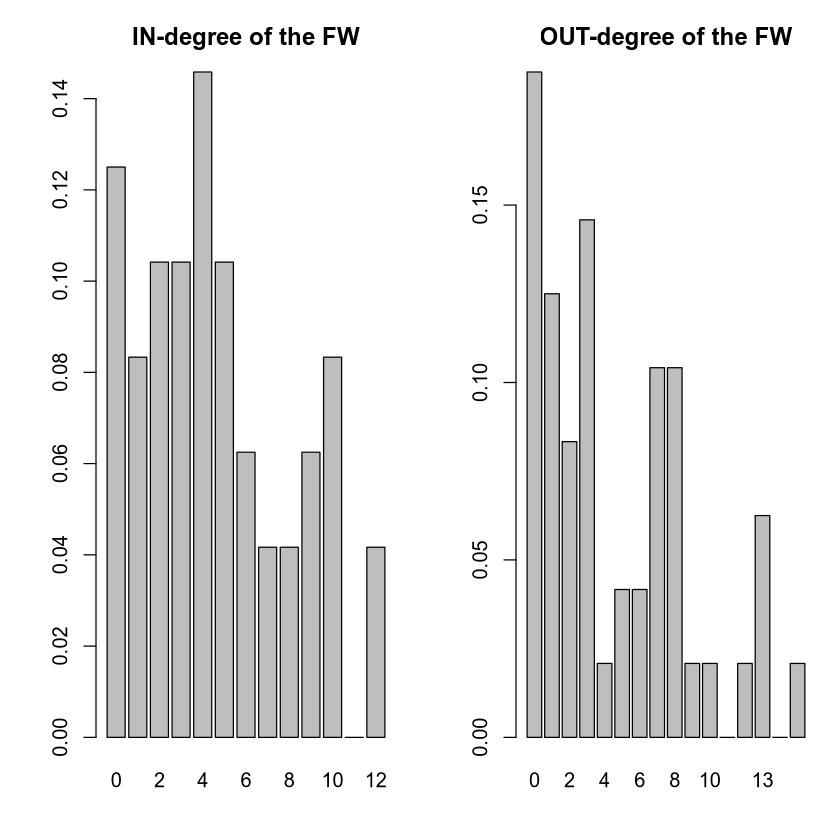

In [2]:
#Load the foodweb
FW_filename<- "./Data/FW_st_marks.csv"
FW_Ilist <- read.csv(FW_filename)
FW <- graph_from_data_frame(FW_Ilist,directed = TRUE)

#obtain the degree sequences
Kin=igraph::degree(FW,mode="in")
Kout=igraph::degree(FW,mode="out")

#obtain the degree distributions
Pin=degree_distribution(FW, mode="in")
Pout=degree_distribution(FW, mode="out")


op <- par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))  # 1 row, 2 columns
barplot(degree_distribution(FW,mode="in"), names.arg=as.character(0:max(igraph::degree(FW,mode="in"))),  main='IN-degree of the FW')
barplot(degree_distribution(FW,mode="out"), names.arg=as.character(0:max(igraph::degree(FW,mode="out"))),  main='OUT-degree of the FW')
par(op)  # restore old graphics settings

We can obtain simple statistics like the average degree, and the standard deviation

In [3]:
Kin_mean=mean(Kin)
Kin_sd=sd(Kin)
Kin_mean
Kin_sd

[1] 4.604167

[1] 3.43164

In [4]:
Kout_mean=mean(Kout)
Kout_sd=sd(Kout)
Kout_mean
Kout_sd

[1] 4.604167

[1] 4.195943

There has been a lot of debate regarding the form of the degree distribution ($P(K)$) in real networks. The best practice to determine which function fits better the $P(K)$) is to use the **cumulative degree distribution** (i.e. how many nodes with degree $K$ or below are in the network) because it is less noisi. 
Let's see how we can do this.

Let's compare the degree distribution of the empirical network with a random one:

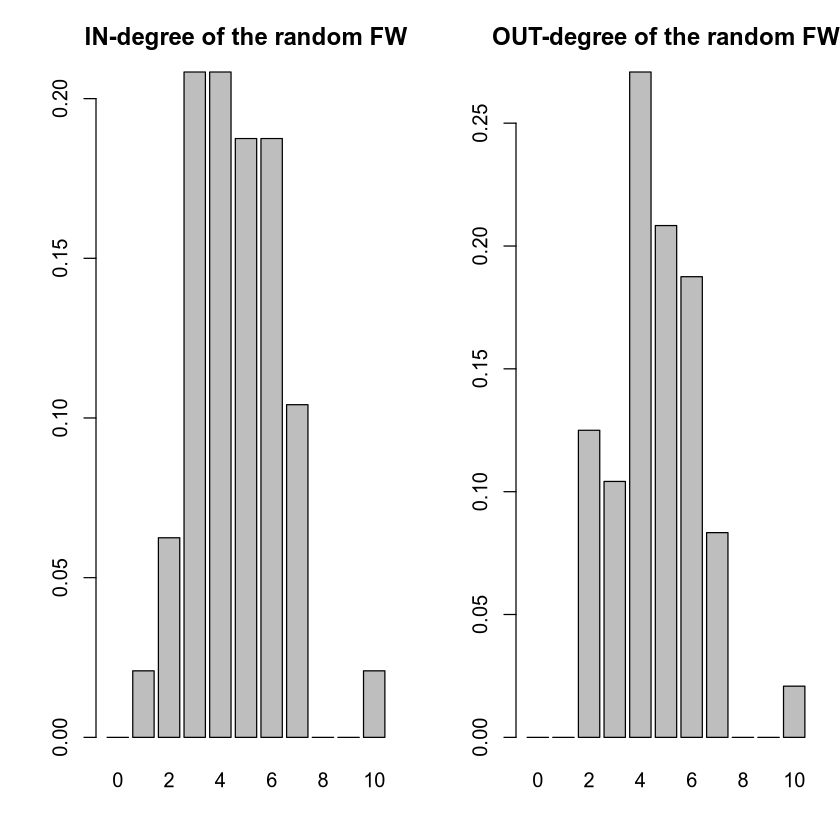

In [5]:
n <- vcount(FW)
m <- ecount(FW)            # preserves mean degrees exactly (m/n)

G0 <- sample_gnm(n, m, directed = TRUE, loops = TRUE)

#obtain the degree sequences
Kin_rnd=igraph::degree(G0,mode="in")
Kout_rnd=igraph::degree(G0,mode="out")

#obtain the degree distributions
Pin_rnd=degree_distribution(G0, mode="in")
Pout_rnd=degree_distribution(G0, mode="out")


op <- par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))  # 1 row, 2 columns
barplot(degree_distribution(G0,mode="in"), names.arg=as.character(0:max(Kin_rnd)),  main='IN-degree of the random FW')
barplot(degree_distribution(G0,mode="out"), names.arg=as.character(0:max(Kout_rnd)),  main='OUT-degree of the random FW')
par(op)  # restore old graphics settings

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


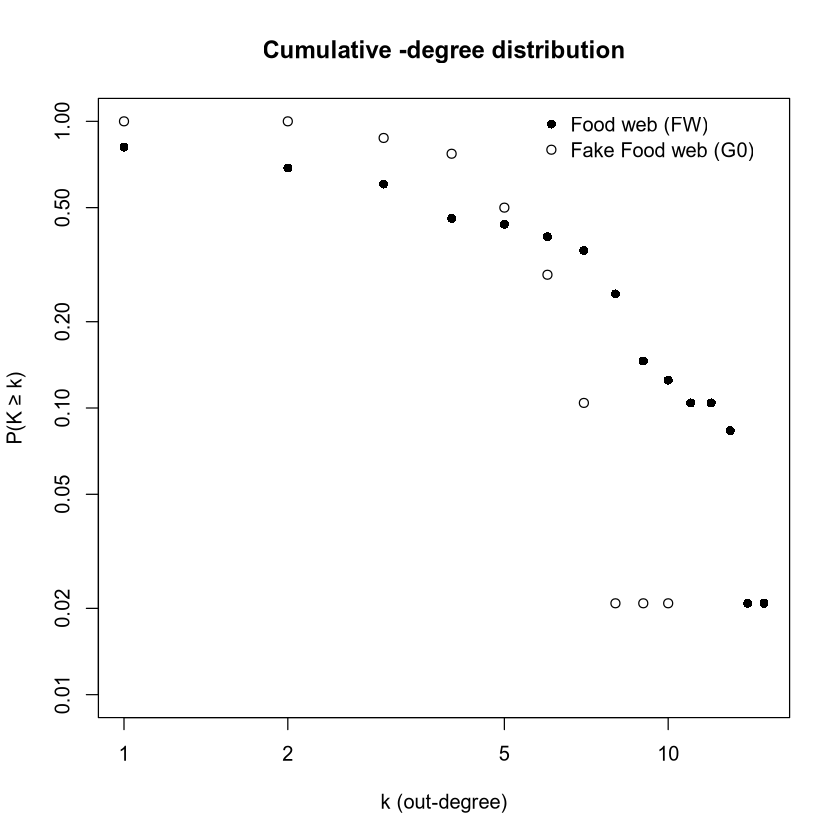

In [6]:
df_FW <- cdf_get(Kout)
df_G0 <- cdf_get(Kout_rnd)

kmax <- max(df_FW$k, df_G0$k)


# 4) plot as points
plot(df_FW$k, df_FW$p,
     pch = 16,
     xlab = "k (out-degree)",
     log="xy",
     ylab = "P(K ≥ k)",
     main = "Cumulative -degree distribution",
     ylim = c(0.01, 1))

points(df_G0$k, df_G0$p, pch = 1)

legend("topright",
       legend = c("Food web (FW)", "Fake Food web (G0)"),
       pch = c(16, 1),
       bty = "n")

#### Generalizing "neighbors" to arbitrarily-sized graphs

The concept of neighbors is simple and appealing,
but it leaves us with a slight point of dissatisfaction:
it is difficult to compare graphs of different sizes.
Is a node more important solely because it has more neighbors?
What if it were situated in an extremely large graph?
Would we not expect it to have more neighbors?

As such, we need a normalization factor.
One reasonable one, in fact, is
_the number of nodes that a given node could **possibly** be connected to._
By taking the ratio of the number of neighbors a node has
to the number of neighbors it could possibly have,
we get the **degree centrality** metric.

Formally defined, the degree centrality of a node (let's call it $d$)
is the number of neighbors that a node has (let's call it $k$, its degree)
divided by the number of neighbors it could _possibly_ have (let's call it $N$, all nodes):

$$d = \frac{k}{N}$$

*igraph* does NOT provide an inbuilt function for this, so the normalization must be done by hand like this:

Degree cenrtality 

`igraph::degree(g) / (igraph::vcount(g) - 1)`

Directed versions:

`igraph::degree(g, mode="in")  / (igraph::vcount(g) - 1)`
`igraph::degree(g, mode="out") / (igraph::vcount(g) - 1)`


> Note: degree centrality is usefull to determine how "central" a node is **across** different networks, since **it does not make sense to compare the raw number of neighbours across networks with different size**!!



## Degree centraility in bipartite networks
When we are working with bipartite networks, we need to take into consideration that we have two different sets of species, and that they can only connect to species in the other set! 

Lets see some examples
In the bipartite case, the maximum possible degree of a node in a bipartite node set is the number of nodes in the opposite node set. The degree centrality for a node $u$ in the bipartite set $U$ with $n$ nodes that is connected to nodes in the bipartite set $V$ with $m$ nodes is
$d_u=\frac{k_u}{m}$, for $u\in U$, and for a node $v$ nodes in set $V$ is $d_v=\frac{k_v}{n}$, for $v\in V$, where $k_v$ is the degree of node v.

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>

<h3> Exercise 8 </h3>
Plot the cumulative degree distribution of the pollinators in the plant-pollinator network provided below, and compare with a random version of it
</div>

> Hint: you can generate a random version of the bipartite network with  
`G0 <- igraph::sample_bipartite(Na, Np, m = L, type="gnm",directed = FALSE)` 

where Na is the number of pollinators, Np number of plants, and L the number of links

In [7]:
#your code here 
P_Filename<-"./Data/Kato_00.csv"

Warning message in readLines(file):
“incomplete final line found on './snippets/ex8.R'”


```r
 df <- read.csv(P_Filename, row.names = 1)
I <- as.matrix(df)
B <- graph_from_biadjacency_matrix(t(I))
Np<-nrow(I)
Na<-ncol(I)
L <- igraph::ecount(B)   

# pollinators = type FALSE, get degree sequence and distribution
polls <- igraph::V(B)[type == FALSE]
Kpol <- igraph::degree(B)[polls]   # degree of pollinators in the bipartite graph

#random bipartiten network with Np,Na and L
G0 <- igraph::sample_bipartite(Na, Np, m = L, type="gnm",directed = FALSE)

#get degree sequence and distribution
polls0 <- igraph::V(G0)[type == FALSE]
Kpol_rnd <- igraph::degree(G0)[polls0]

df_B  <- cdf_get(Kpol)
df_G0 <- cdf_get(Kpol_rnd)

plot(df_B$k, df_B$p,
     pch = 16,
     log = "xy",
     xlab = "k (pollinator degree)",
     ylab = "P(K ≥ k)",
     main = "Cumulative degree distribution of polinators",
     ylim = c(0.001, 1))

points(df_G0$k, df_G0$p, pch = 1)

legend("topright",
       legend = c("Empirical (B)", "Random bipartite (G0)"),
       pch = c(16, 1),
       bty = "n")
        
```

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


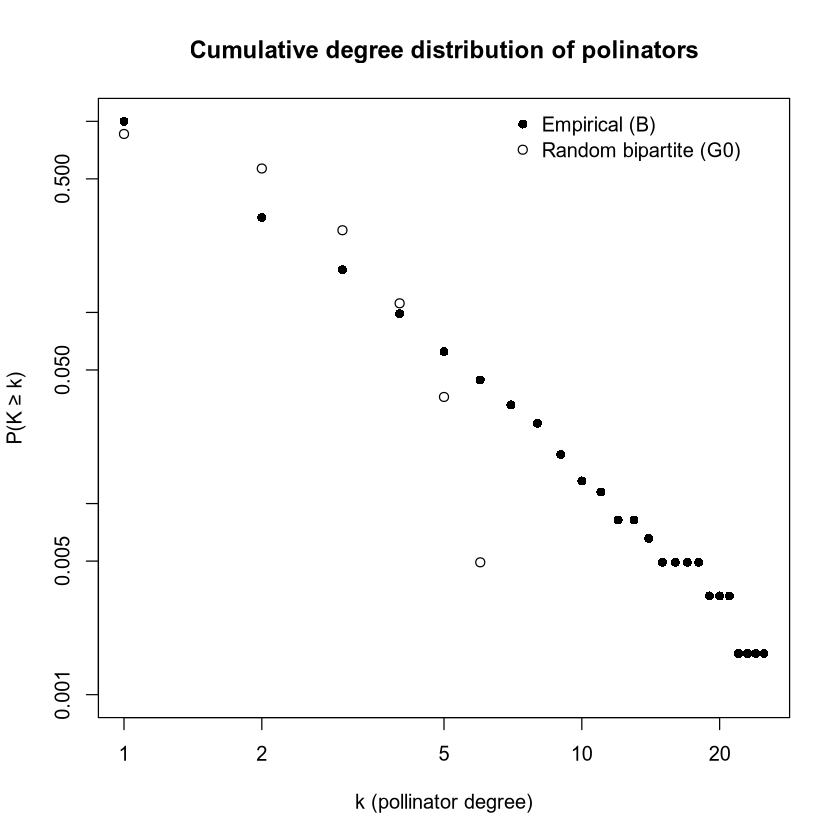

In [8]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex8.R")

### Common centrality metrics

As we have seen before, one can be "important" in different ways. 
*igraph* provides the most common metrics of node centrality
- `degree(g)`                        # Degree centrality
- `closeness(g)`                     # Closeness centrality
- `betweenness(g)`                   # Vertex betweenness centrality
- `eigen_centrality(g)$vector`       # Eigenvector centrality


The importances of the nodes does not always necesarily coincides. Let's see it in our foodweb

In [33]:
#compute several metrics of node centrality, and store them in the graph nodes
V(FW)$degree <- igraph::degree(FW)                        # Degree centrality
V(FW)$eig <- igraph::eigen_centrality(FW)$vector                    # Eigenvector centrality
V(FW)$closeness <- igraph::closeness(FW)                  # Closeness centrality
V(FW)$betweenness <- igraph::betweenness(FW)              # Vertex betweenness centrality
#V(FW)$pr <- igraph::page_rank(B)$vector                  # Page rank

#createa a datafram of centrlity metrics 
centrality_df <- data.frame(row.names   = V(FW)$name,
                         degree      = V(FW)$degree,
                         closeness   = V(FW)$closeness,
                         betweenness = V(FW)$betweenness,
                         eigenvector = V(FW)$eig)


In [38]:
V(FW)$closeness

[1] 0.2857142857 0.0035816619 0.0012742100 0.0036258158 2.0000000000
 [6] 0.0344827586 0.0526315789 0.0029455081 0.0125156446 0.0080000000
[11] 0.0017553098 0.0063451777 2.0000000000 1.0000000000 0.1111111111
[16] 0.0019972039 0.0062695925 0.0034364261 0.0077519380 0.2000000000
[21] 0.0010274324 0.0033523299 0.0012195122 0.0053276505 0.0063211125
[26] 0.0051020408 0.0106723586 0.0009728573 0.0769230769 0.0465116279
[31] 0.0130548303 0.0063091483 0.5000000000 0.1587301587 0.1333333333
[36] 0.0035335689 0.0135317997 0.0181818182 0.0288184438          NaN
[41]          NaN          NaN          NaN          NaN          NaN
[46]          NaN          NaN          NaN

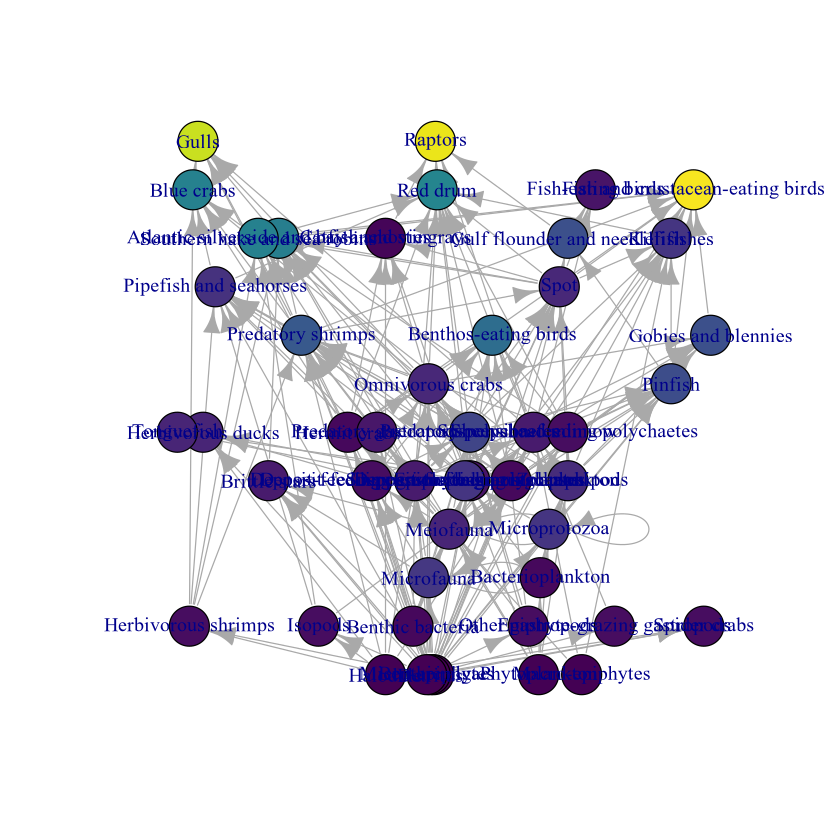

In [ ]:
color<- V(FW)$closeness
plot_as_flux(
  FW,
  vertex.color = viridis::viridis(100)[
    floor(
      (V(FW)$pagerank - min(V(FW)$pagerank, na.rm=TRUE)) /
      (max(V(FW)$pagerank, na.rm=TRUE) - min(V(FW)$pagerank, na.rm=TRUE) + 1e-12) * 99
    ) + 1
  ]
)

In [26]:
V(B)$degree <- igraph::degree(B)                        # Degree centrality
V(B)$eig <- igraph::eigen_centrality(B)$vector                    # Eigenvector centrality
V(B)$closeness <- igraph::closeness(B)                  # Closeness centrality
V(B)$betweenness <- igraph::betweenness(B)              # Vertex betweenness centrality
V(B)$pr <- igraph::page_rank(B)$vector                  # Page rank

res <- get_MusRank(I, mode = "ranking", niterations = 100, seed = 1)
V(B)[!type]$FC <- res$animal_fitness[V(B)[!type]$name]  #fitness-complexity for animals and plants
V(B)[ type]$FC <- res$plant_complexity[V(B)[ type]$name]

centrality_df <- data.frame(row.names   = V(B)$name,
                         type = V(B)$type,
                         degree      = V(B)$degree,
                         closeness   = V(B)$closeness,
                         betweenness = V(B)$betweenness,
                         eigenvector = V(B)$eig,
                         pagerank = V(B)$pr,
                         FC = V(B)$FC)

### K_core decomposition
The k-core of a graph is a maximal subgraph in which every vertex has at least degree kk.
It’s a way to iteratively remove nodes with degree less than kk, resulting in progressively smaller subgraphs.
k-core decomposition identifies these subgraphs for varying values of kk. The larger the kk, the more "central" or "core" the remaining nodes are considered to be in the graph's structure.

For example, a 2-core would be a subgraph where all nodes have at least degree 2, meaning each node is connected to at least two other nodes.
The process continues by removing nodes with degrees less than kk until the condition is met.

### Page Rank

PageRank computes a ranking of the nodes in the graph G based on the structure of the incoming links. It was originally designed as an algorithm to rank web pages.
However, it can also be used to identify the species that "move" more biomass trough a network, or in general, the node that is most used when trasnporting information trough the graph. Since this is only interesting in **directed graphs** let's use one of our directed networks. It has been used, for example, to find what are the nodes that are pointing to the more "important" nodes, in order to find the species that can cause more harm when they disapear from the network.

In [ ]:
- `page_rank(g)$vector`              # Page rank 

### Fitness-Complexity

In [28]:
cor(centrality_df, method = "spearman") 

,type,degree,closeness,betweenness,eigenvector,pagerank,FC
type,1.00000000,0.4130862,0.07037996,0.4018638,0.03207381,0.4199282,0.3125569
degree,0.41308625,1.0000000,0.55926519,0.9939983,0.54045592,0.8629757,0.3481628
closeness,0.07037996,0.5592652,1.00000000,0.5521371,0.91688942,0.3573446,-0.2953909
betweenness,0.40186380,0.9939983,0.55213715,1.0000000,0.53225865,0.8615128,0.3488908
eigenvector,0.03207381,0.5404559,0.91688942,0.5322586,1.00000000,0.2682842,-0.3737186
pagerank,0.41992825,0.8629757,0.35734458,0.8615128,0.26828425,1.0000000,0.4327672
FC,0.31255691,0.3481628,-0.29539086,0.3488908,-0.37371861,0.4327672,1.0000000


## 2B Global scale (community)

## 2C Meso-Scale

### Paths 

A *path* in a network is a sequence of edges connecting two nodes. Let's start with a very simple, undirected network.

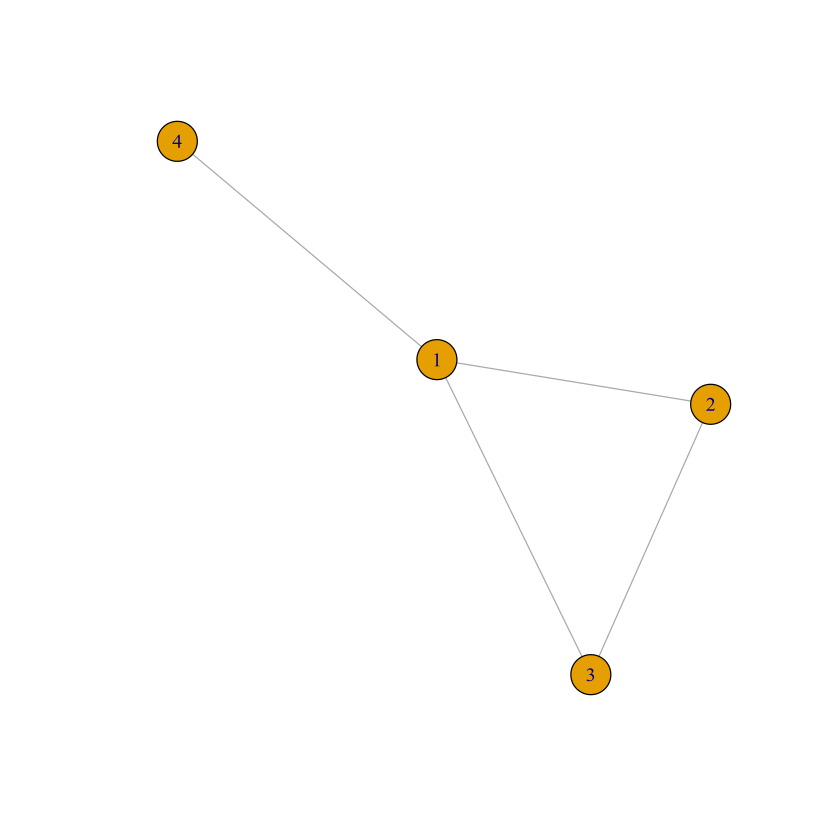

In [ ]:
# Create empty undirected graph
G <- make_empty_graph(directed = FALSE)
# Add nodes
G <- add_vertices(G, 4, name = c("1","2","3","4"))
# Add edges
G <- add_edges(G, c("1","2",
                     "2","3",
                     "1","3",
                     "1","4"))

# Plot
plot(G, vertex.label = V(G)$name)

 this simple example, we can easily see that there is indeed at least one path that connects nodes 3 and 4. There can be more than one path between two nodes. Again considering nodes 3 and 4, there are two such "simple" paths that we can retrieve with `all_simple_paths(g,start,end)`

In [ ]:
all_simple_paths(G, 3, 4)

[[1]]
+ 3/4 vertices, named, from 5867f30:
[1] 3 1 4

[[2]]
+ 4/4 vertices, named, from 5867f30:
[1] 3 2 1 4


We are often most interested in **shortest paths**. In an unweighted network, the shortest path is the one with the fewest edges. 
We can see that of the two simple paths between nodes 3 and 4, one is shorter than the other. 
We can get this shortest path with a single igraph function `all_shortest_path(G, start node, end node)$vpath[[1]]`

In [ ]:
all_shortest_paths(G,3,4)$vpath[[1]] #vpath indicates we are only intersted in the node paths, i.e. going from one node to another

+ 3/4 vertices, named, from 5867f30:
[1] 3 1 4

OR if you want to retrieve the names of the nodes

In [ ]:
all_shortest_paths(G,3,4)$vpath[[1]]$name

[1] "3" "1" "4"

If you only care about the path length, there's a function for that too: `nx.shortest_path_length(G, start node, end node)`

In [ ]:
as.numeric(igraph::distances(G, 3, 4))

[1] 2

> Note that a path length is defined here by the number of *edges* in the path, not the number of nodes, which implies that for nodes $u$ and $v$.
>
>    `as.numeric(igraph::distances(G, 3, 4)) == length(all_shortest_paths(G,3,4)$vpath[[1]]$name) - 1`
   

You can also obtain the average shortest path length between any pair of nodes in the network with `igraph::mean_distance(G)`, and the maximum shortest path length (or network diameter) with `igraph::diameter(G)`

In [ ]:
igraph::mean_distance(G)

[1] 1.333333

In [ ]:
igraph::diameter(G)

[1] 2

Let's extend these ideas about paths to directed graphs.
#### Directed paths

We know that in a directed graph, an edge from an arbitrary node $u$ to an arbitrary node $v$ does not imply that an edge exists from $v$ to $u$. Since paths must follow edge direction in directed graphs, the same asymmetry applies for paths. Observe that this graph has a path from 1 to 4, but not in the reverse direction.

Warning message:
“`graph()` was deprecated in igraph 2.1.0.
ℹ Please use `make_graph()` instead.”


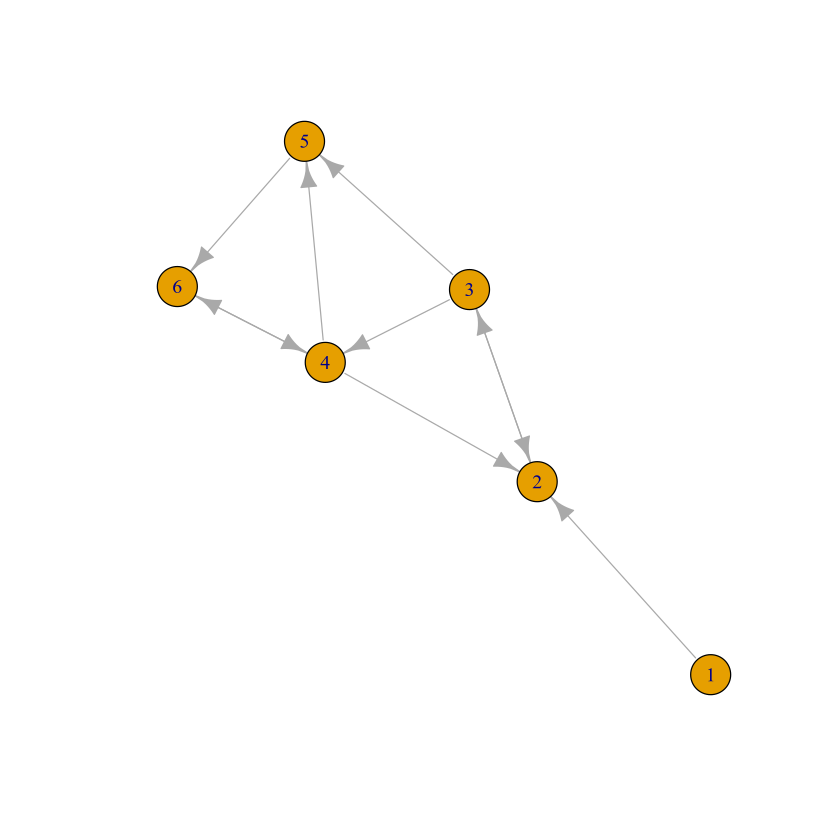

In [ ]:
edges <- c(
  1,2,
  2,3,
  3,2,  3,4,  3,5,
  4,2,  4,5,  4,6,
  5,6,
  6,4
)
D <- graph(edges, directed = TRUE)
plot(D)

Can I go from node 1 to 4?  And form node 4 to 1?

In [ ]:
as.numeric(igraph::distances(D, 1, 4,mode="out")) #from 1 to 4
as.numeric(igraph::distances(D, 4, 1,mode="out")) #from 4 to 1

[1] 3

[1] Inf

For shortest path we also have to take it into account
> Note: Since there is no edge from 5 to 3, the shortest path from 5 to 2 cannot simply backtrack the shortest path from 2 to 5 -- it has to go a longer route through nodes 6 and 4.

In [ ]:
shortest_paths(D, 2, 5, mode = "out")$vpath[[1]]
shortest_paths(D, 5, 2, mode = "out")$vpath[[1]]

+ 3/6 vertices, from 5edbaab:
[1] 2 3 5

+ 4/6 vertices, from 5edbaab:
[1] 5 6 4 2

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>
<h4> Exercise 7</h4>
Imagine that after an accident, the 'Suspension-feeding molluscs' have been contaminated with lead. Taking into cosideration the structure of the trophic interactions in the St Marks estudary, aswer the following questions:
    
- 1 Should we be worried about the well fare of the 'Tonguefish'? 
- 2 and what about the 'Fish and crustacean-eating birds'?
- 3 Should we expect more accumulation of lead in 'Herbivorous ducks' or in 'Fish and crustacean-eating birds', according to their diets? (hint: only consider length of trophic chain)
    
![title](./images/figure10.jpg)
</div>

In [ ]:
# your code here . Remember we have loaded the network before, look how to do it
FW_filename<- "./Data/FW_st_marks.csv"


In [ ]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex7.R")


```r
 #load the network
FW_Ilist <- read.csv(FW_filename)
FW <- graph_from_data_frame(FW_Ilist,directed = TRUE)

sp0='Suspension-feeding molluscs'
sp1='Tonguefish'
sp2='Fish and crustacean-eating birds'
sp3='Herbivorous ducks' 

#1) Do Tonguefish eat molluscs?
sp0_sp1=as.numeric(igraph::distances(FW,sp0,sp1,mode="out"))
cat(sprintf("1. It is %s that %s depends on %s\n",  is.finite(sp0_sp1), sp1, sp0
))

#2) and the Fish and crustacean eating birds?
sp0_sp2=as.numeric(igraph::distances(FW,sp0,sp2),mode="out")
cat(sprintf("2. It is %s that %s depends on %s\n",  is.finite(sp0_sp2), sp2, sp0
))

#3) Should ducka or birds accumulate more lead?
L2=igraph::distances(FW,sp0,sp2,mode="out",weights = NA)
L3=igraph::distances(FW,sp0,sp3,mode="out",weights=NA)

if (L2 < L3) {
  cat(sprintf("3. %s are in more danger since they are only %s steps away and %s are %s steps away\n",sp2, L2, sp3, L3
  ))
} else {
  cat(sprintf("3. %s are in more danger since they are only %s steps away and %s are %s step

[1] 2.524876